In [2]:
# ==============================
# SECTION : Imports
# ==============================

import os
import glob
import numpy as np
import pandas as pd
import random

from tqdm import tqdm

# Audio
import librosa
import librosa.display
import soundfile as sf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.svm import SVC
from sklearn.cluster import KMeans

# Deep Learning
import tensorflow as tf

from tensorflow.keras.models import (
    Sequential,
    Model
)

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Flatten,
    Reshape,
    Conv1D,
    Conv2D,
    MaxPooling1D,
    MaxPooling2D,
    LSTM,
    Bidirectional
)
from tensorflow.keras.callbacks import ReduceLROnPlateau

from tensorflow.keras.callbacks import EarlyStopping
# from transformers import AutoProcessor, TFAutoModel
# from tensorflow.keras.callbacks import ModelCheckpoint

In [3]:
# SECTION 1: Dataset Config

DATA_PATH = "/Users/cryptelle/Downloads/remake"

TARGET_SR = 16000
TARGET_SEC = 3
TARGET_LEN = TARGET_SR * TARGET_SEC

TOP_DB = 30
FRAME_LENGTH = 2048
HOP_LENGTH = 512

N_MELS = 128
N_FFT = 1024

In [4]:
# SECTION 2: Collect WAV Files

wav_paths = glob.glob(
    os.path.join(DATA_PATH, "**", "*.wav"),
    recursive=True
)

wav_files = [
    os.path.basename(f)
    for f in wav_paths
]

print("Total WAV files:", len(wav_paths))
print("First 10 paths:")
print(wav_paths[:10])

Total WAV files: 3870
First 10 paths:
['/Users/cryptelle/Downloads/remake/0/50-f-5-0-2-37.wav', '/Users/cryptelle/Downloads/remake/0/26-m-19-0-0-127.wav', '/Users/cryptelle/Downloads/remake/0/56-f-40-0-2-94.wav', '/Users/cryptelle/Downloads/remake/0/9-f-20-0-1-104.wav', '/Users/cryptelle/Downloads/remake/0/43-m-41-0-1-154.wav', '/Users/cryptelle/Downloads/remake/0/47-m-20-0-2-171.wav', '/Users/cryptelle/Downloads/remake/0/53-m-20-0-2-211.wav', '/Users/cryptelle/Downloads/remake/0/56-f-40-0-0-52.wav', '/Users/cryptelle/Downloads/remake/0/11-m-23-0-0-108.wav', '/Users/cryptelle/Downloads/remake/0/49-m-23-0-2-198.wav']


In [5]:


for f in random.sample(wav_files, 10):
    print(f)

50-f-5-0-1-26.wav
55-m-16-4-0-1328.wav
2-m-25-4-1-1197.wav
50-f-5-4-2-1124.wav
50-f-5-4-2-1122.wav
55-m-16-0-2-248.wav
54-f-19-6-1-1645.wav
25-m-19-2-2-680.wav
50-f-5-5-0-1374.wav
47-m-20-6-0-1731.wav


In [6]:
# SECTION 3: Labels

def get_emotion(fname):

    base = os.path.splitext(fname)[0]
    parts = base.split("-")

    return int(parts[4])   # spoken_emotion


df = pd.DataFrame({
    "file": wav_files,
    "path": wav_paths
})

df["y"] = df["file"].apply(get_emotion)

EMO_MAP = {
    0: "Low",
    1: "Neutral",
    2: "High"
}

df["emotion_name"] = df["y"].map(EMO_MAP)

df2 = df.copy()
df2["y"] = df2["y"].astype(int)

print(df2["emotion_name"].value_counts())
print(df2.head())

emotion_name
High       1356
Neutral    1344
Low        1170
Name: count, dtype: int64
                  file                                               path  y  \
0    50-f-5-0-2-37.wav  /Users/cryptelle/Downloads/remake/0/50-f-5-0-2...  2   
1  26-m-19-0-0-127.wav  /Users/cryptelle/Downloads/remake/0/26-m-19-0-...  0   
2   56-f-40-0-2-94.wav  /Users/cryptelle/Downloads/remake/0/56-f-40-0-...  2   
3   9-f-20-0-1-104.wav  /Users/cryptelle/Downloads/remake/0/9-f-20-0-1...  1   
4  43-m-41-0-1-154.wav  /Users/cryptelle/Downloads/remake/0/43-m-41-0-...  1   

  emotion_name  
0         High  
1          Low  
2         High  
3      Neutral  
4      Neutral  


In [7]:
# SECTION 4: Audio Preprocessing

def preprocess_audio(path):

    y, sr = librosa.load(
        path,
        sr=TARGET_SR,
        mono=True
    )

    # Remove silence
    y_trim, _ = librosa.effects.trim(
        y,
        top_db=TOP_DB,
        frame_length=FRAME_LENGTH,
        hop_length=HOP_LENGTH
    )

    # Safety fallback
    if len(y_trim) < 10:
        y_trim = y

    # Normalize
    peak = np.max(np.abs(y_trim)) + 1e-9

    y_trim = y_trim / peak

    # Fixed length
    if len(y_trim) > TARGET_LEN:

        y_trim = y_trim[:TARGET_LEN]

    else:

        y_trim = np.pad(
            y_trim,
            (0, TARGET_LEN - len(y_trim))
        )

    return y_trim

In [8]:
# SECTION 5: Augmentation

def add_noise(data, noise_factor=0.005):

    noise = np.random.randn(len(data))

    return data + noise_factor * noise


def shift_pitch(data, sr, n_steps=2):

    return librosa.effects.pitch_shift(
        data,
        sr=sr,
        n_steps=n_steps
    )


def time_shift(data, shift_max=0.2):

    shift = int(
        np.random.uniform(-shift_max, shift_max)
        * len(data)
    )

    return np.roll(data, shift)


def change_volume(data):

    gain = np.random.uniform(0.8, 1.2)

    return data * gain

In [9]:
# SECTION 6: Build Waveforms

X_wave = np.zeros(
    (len(df2), TARGET_LEN),
    dtype=np.float32
)

for i, path in enumerate(
    tqdm(df2["path"], desc="Processing Audio")
):

    X_wave[i] = preprocess_audio(path)

print("X_wave shape:", X_wave.shape)

Processing Audio: 100%|████████████████████| 3870/3870 [00:05<00:00, 671.39it/s]

X_wave shape: (3870, 48000)


Before: 2.304
After: 3.0


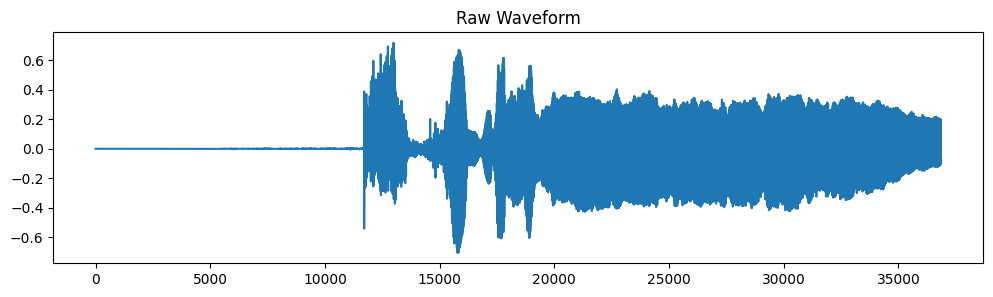

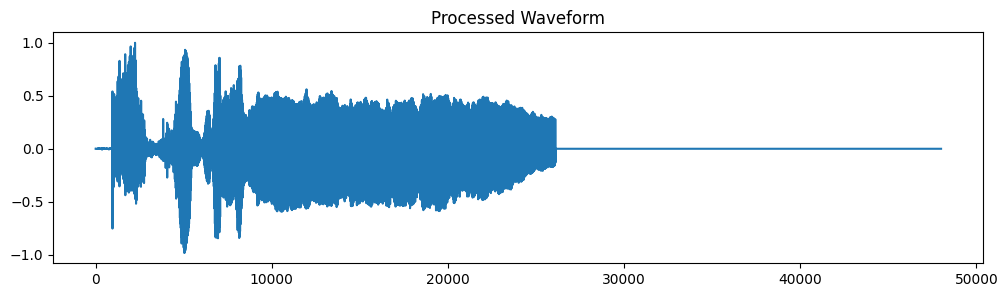

In [10]:
# Visualization: Before/After Preprocessing

test_path = df2["path"].iloc[0]

# قبل المعالجة
y_raw, _ = librosa.load(
    test_path,
    sr=TARGET_SR
)

# بعد المعالجة
y_processed = preprocess_audio(
    test_path
)

print("Before:", len(y_raw)/TARGET_SR)
print("After:", len(y_processed)/TARGET_SR)

plt.figure(figsize=(12,3))
plt.plot(y_raw)
plt.title("Raw Waveform")
plt.show()

plt.figure(figsize=(12,3))
plt.plot(y_processed)
plt.title("Processed Waveform")
plt.show()

In [11]:
# SECTION 7: Log-Mel Extraction

def waveform_to_logmel(y):

    S = librosa.feature.melspectrogram(
        y=y,
        sr=TARGET_SR,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    logS = librosa.power_to_db(
        S,
        ref=np.max
    )

    target_width = 94

    if logS.shape[1] < target_width:

        pad = target_width - logS.shape[1]

        logS = np.pad(
            logS,
            ((0,0),(0,pad)),
            mode='constant'
        )

    else:

        logS = logS[:, :target_width]

    return logS

In [12]:
# SECTION 8: Feature Extraction

X_mel_list = []
y_augmented = []

for i in tqdm(range(len(df2))):

    y_wave = X_wave[i]

    label = df2["y"].iloc[i]

    # Original
    mel = waveform_to_logmel(y_wave)

    X_mel_list.append(mel)
    y_augmented.append(label)

    # Noise
    noisy = add_noise(y_wave)

    mel_noise = waveform_to_logmel(noisy)

    X_mel_list.append(mel_noise)
    y_augmented.append(label)

    # Pitch Shift
    pitched = shift_pitch(
        y_wave,
        TARGET_SR
    )

    mel_pitch = waveform_to_logmel(pitched)

    X_mel_list.append(mel_pitch)
    y_augmented.append(label)

    # Time Shift
    shifted = time_shift(y_wave)

    mel_shift = waveform_to_logmel(shifted)

    X_mel_list.append(mel_shift)
    y_augmented.append(label)

    # Volume Change
    volume = change_volume(y_wave)

    mel_volume = waveform_to_logmel(volume)

    X_mel_list.append(mel_volume)
    y_augmented.append(label)


X = np.array(
    X_mel_list,
    dtype=np.float32
)

X = X[..., np.newaxis]

y = np.array(y_augmented)

print(X.shape)
print(y.shape)

100%|███████████████████████████████████████| 3870/3870 [01:46<00:00, 36.36it/s]


(19350, 128, 94, 1)
(19350,)


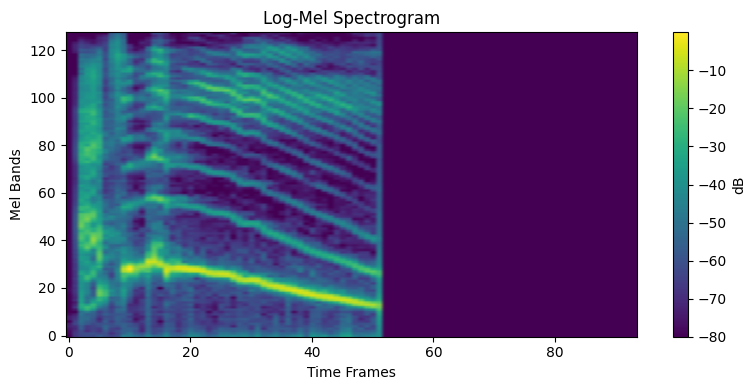

In [13]:
# Visualization: Log-Mel Spectrogram

idx = 0

mel_img = X[idx, :, :, 0]

plt.figure(figsize=(8,4))

plt.imshow(
    mel_img,
    aspect='auto',
    origin='lower'
)

plt.title("Log-Mel Spectrogram")

plt.xlabel("Time Frames")
plt.ylabel("Mel Bands")

plt.colorbar(label='dB')

plt.tight_layout()

plt.show()

In [14]:
# SECTION 9: Normalization

eps = 1e-9

mean_per_sample = X.mean(
    axis=(1,2,3),
    keepdims=True
)

std_per_sample = X.std(
    axis=(1,2,3),
    keepdims=True
)

X = (
    X - mean_per_sample
) / (
    std_per_sample + eps
)

In [15]:
# SECTION 10: LSTM Input

X_lstm = X.squeeze(-1)

X_lstm = np.transpose(
    X_lstm,
    (0, 2, 1)
)

print(X_lstm.shape)

(19350, 94, 128)


In [16]:
# SECTION 11: Split Data

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# LSTM split
Xl_train, Xl_temp, yl_train, yl_temp = train_test_split(
    X_lstm,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

Xl_val, Xl_test, yl_val, yl_test = train_test_split(
    Xl_temp,
    yl_temp,
    test_size=0.50,
    random_state=42,
    stratify=yl_temp
)

In [17]:
# SECTION 12: Helper Functions

target_names = [
    "Low",
    "Neutral",
    "High"
]

def plot_training_curves(history, model_name):

    # Accuracy
    plt.figure(figsize=(10,4))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Loss
    plt.figure(figsize=(10,4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


def evaluate_model(model, X_test_data, y_test_data, model_name):

    test_loss, test_acc = model.evaluate(
        X_test_data,
        y_test_data
    )

    print(f"{model_name} Accuracy:", test_acc)

    y_pred = model.predict(X_test_data)
    y_pred = np.argmax(y_pred, axis=1)

    print(f"\n{model_name} Classification Report:")
    print(
        classification_report(
            y_test_data,
            y_pred,
            target_names=target_names
        )
    )

    cm = confusion_matrix(
        y_test_data,
        y_pred
    )

    plt.figure(figsize=(6,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return test_acc, y_pred

In [18]:
# SECTION 13: CNN  Model

cnn_model = Sequential()

cnn_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(128,94,1)
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.25))

cnn_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.25))

cnn_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.3))

cnn_model.add(Flatten())

cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(0.4))

cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.3))

cnn_model.add(Dense(3, activation='softmax'))

cnn_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

cnn_model.summary()

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-14 14:18:12.271641: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-05-14 14:18:12.271927: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-14 14:18:12.271939: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-14 14:18:12.272260: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-14 14:18:12.272277: I tensorflow/core/common_runtime/pluggable_device/pluggable_de

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 94, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 94, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 22528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     5,767,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,894,275 (22.48 MB)

 Trainable params: 5,893,827 (22.48 MB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
# SECTION 14: CNN Training

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

cnn_history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50


2026-05-14 14:18:15.559187: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


424/424 ━━━━━━━━━━━━━━━━━━━━ 34s 62ms/step - accuracy: 0.4100 - loss: 32.7249 - val_accuracy: 0.4928 - val_loss: 8.3317 - learning_rate: 5.0000e-04
Epoch 2/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.5134 - loss: 21.1431 - val_accuracy: 0.6533 - val_loss: 6.3807 - learning_rate: 5.0000e-04
Epoch 3/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.5976 - loss: 11.3912 - val_accuracy: 0.6968 - val_loss: 3.2603 - learning_rate: 5.0000e-04
Epoch 4/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.6413 - loss: 4.3749 - val_accuracy: 0.7505 - val_loss: 1.1885 - learning_rate: 5.0000e-04
Epoch 5/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.6599 - loss: 1.3815 - val_accuracy: 0.7088 - val_loss: 0.8888 - learning_rate: 5.0000e-04
Epoch 6/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - accuracy: 0.6750 - loss: 0.9617 - val_accuracy: 0.7126 - val_loss: 0.7786 - learning_rate: 5.0000e-04
Epoch 7/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - accu

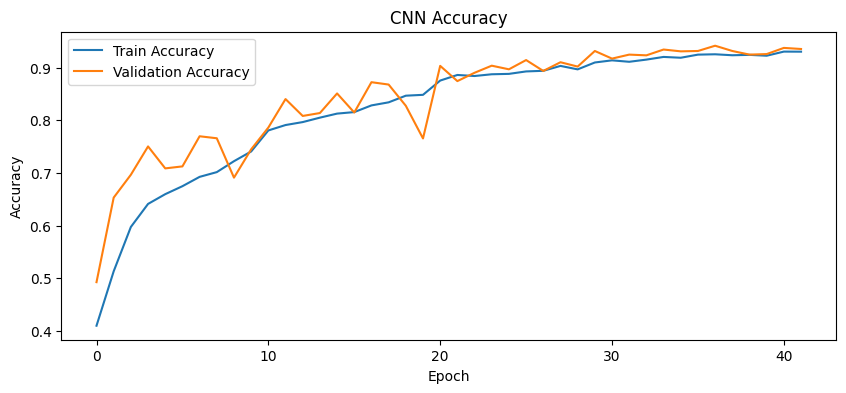

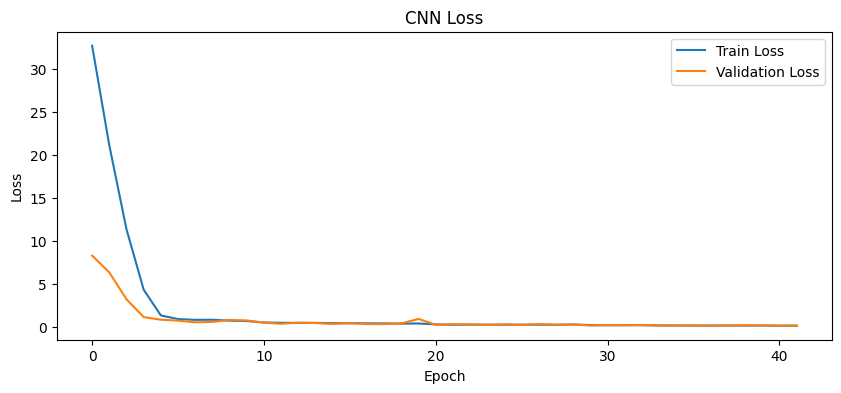

91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9394 - loss: 0.1959
CNN Accuracy: 0.9393730759620667
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

CNN Classification Report:
              precision    recall  f1-score   support

         Low       0.93      0.95      0.94       878
     Neutral       0.93      0.91      0.92      1008
        High       0.96      0.96      0.96      1017

    accuracy                           0.94      2903
   macro avg       0.94      0.94      0.94      2903
weighted avg       0.94      0.94      0.94      2903



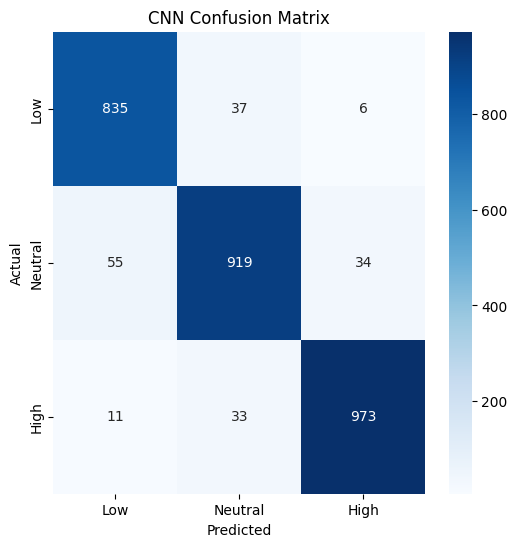

In [40]:
# SECTION 15: CNN Evaluation

plot_training_curves(
    cnn_history,
    "CNN"
)

cnn_test_acc, y_pred_cnn = evaluate_model(
    cnn_model,
    X_test,
    y_test,
    "CNN"
)

In [21]:
# SECTION 16: LSTM Independent Model

lstm_only_model = Sequential()

lstm_only_model.add(
    LSTM(
        64,
        input_shape=(94, 128)
    )
)

lstm_only_model.add(
    Dense(
        128,
        activation="relu"
    )
)

lstm_only_model.add(
    Dropout(0.3)
)

lstm_only_model.add(
    Dense(
        3,
        activation="softmax"
    )
)

lstm_only_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

lstm_only_model.summary()

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,115 (227.01 KB)

 Trainable params: 58,115 (227.01 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# SECTION 17: LSTM Training

history_lstm_only = lstm_only_model.fit(
    Xl_train,
    yl_train,
    validation_data=(Xl_val, yl_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.3934 - loss: 1.0929 - val_accuracy: 0.4035 - val_loss: 1.0710 - learning_rate: 5.0000e-04
Epoch 2/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.4620 - loss: 1.0288 - val_accuracy: 0.5579 - val_loss: 0.9070 - learning_rate: 5.0000e-04
Epoch 3/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.5897 - loss: 0.8455 - val_accuracy: 0.6227 - val_loss: 0.7818 - learning_rate: 5.0000e-04
Epoch 4/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.6547 - loss: 0.7226 - val_accuracy: 0.6602 - val_loss: 0.7414 - learning_rate: 2.5000e-04
Epoch 5/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.6836 - loss: 0.6695 - val_accuracy: 0.6909 - val_loss: 0.6690 - learning_rate: 2.5000e-04


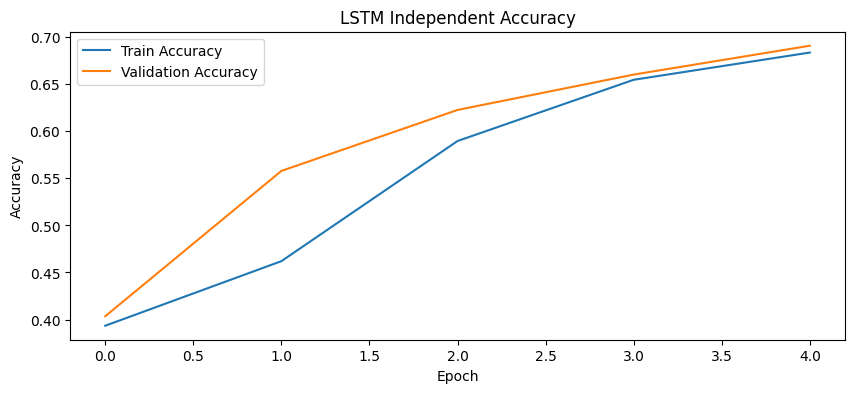

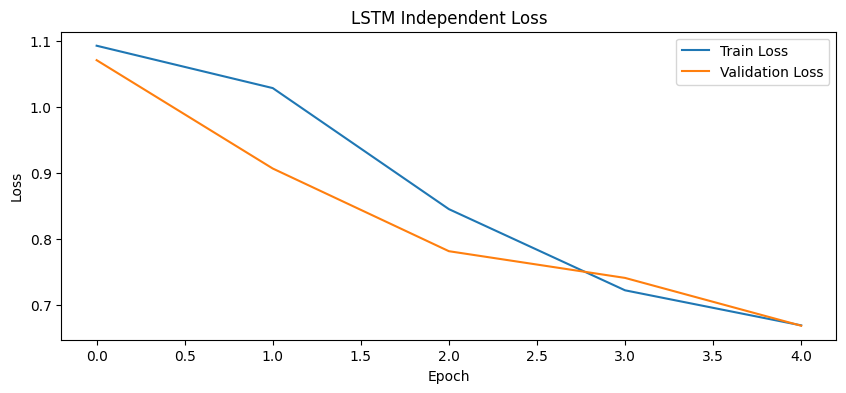

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4092 - loss: 1.0692
LSTM Independent Accuracy: 0.40923184156417847
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

LSTM Independent Classification Report:
              precision    recall  f1-score   support

         Low       0.61      0.10      0.17       878
     Neutral       0.44      0.21      0.29      1008
        High       0.39      0.88      0.54      1017

    accuracy                           0.41      2903
   macro avg       0.48      0.39      0.33      2903
weighted avg       0.47      0.41      0.34      2903



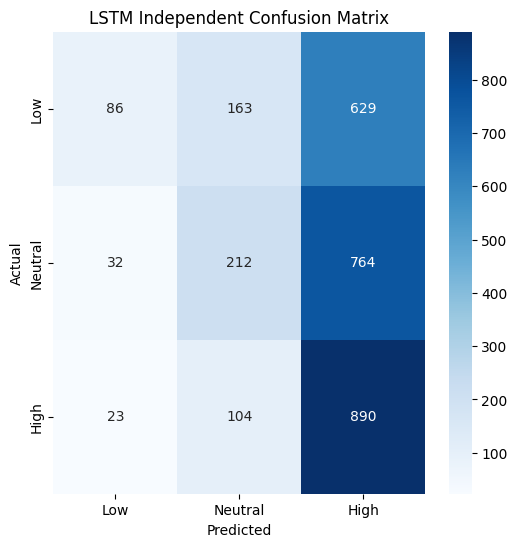

In [23]:
# SECTION 18: LSTM Evaluation

plot_training_curves(
    history_lstm_only,
    "LSTM Independent"
)

test_acc_lstm_only, y_pred_lstm_only = evaluate_model(
    lstm_only_model,
    Xl_test,
    yl_test,
    "LSTM Independent"
)

In [24]:
# SECTION 16: CNN + LSTM

model_lstm = Sequential()

model_lstm.add(
    Conv1D(
        64,
        3,
        activation='relu',
        input_shape=(94,128)
    )
)

model_lstm.add(
    BatchNormalization()
)

model_lstm.add(
    MaxPooling1D(2)
)

model_lstm.add(
    Conv1D(
        128,
        3,
        activation='relu'
    )
)

model_lstm.add(
    BatchNormalization()
)

model_lstm.add(
    MaxPooling1D(2)
)

model_lstm.add(
    LSTM(64)
)

model_lstm.add(
    Dense(
        128,
        activation='relu'
    )
)

model_lstm.add(
    Dropout(0.3)
)

model_lstm.add(
    Dense(
        3,
        activation='softmax'
    )
)

model_lstm.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

model_lstm.summary()

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 92, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 92, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 44, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 44, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,227 (422.76 KB)

 Trainable params: 107,843 (421.26 KB)

 Non-trainable params: 384 (1.50 KB)

In [25]:
# SECTION 17: CNN+LSTM Training

history_lstm = model_lstm.fit(
    Xl_train,
    yl_train,
    validation_data=(Xl_val, yl_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.5271 - loss: 0.9366 - val_accuracy: 0.5569 - val_loss: 0.9298 - learning_rate: 5.0000e-04
Epoch 2/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.6914 - loss: 0.6859 - val_accuracy: 0.7195 - val_loss: 0.6229 - learning_rate: 5.0000e-04
Epoch 3/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7505 - loss: 0.5646 - val_accuracy: 0.7295 - val_loss: 0.5580 - learning_rate: 5.0000e-04
Epoch 4/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8226 - loss: 0.4167 - val_accuracy: 0.8394 - val_loss: 0.4026 - learning_rate: 2.5000e-04
Epoch 5/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8594 - loss: 0.3450 - val_accuracy: 0.8529 - val_loss: 0.3832 - learning_rate: 2.5000e-04


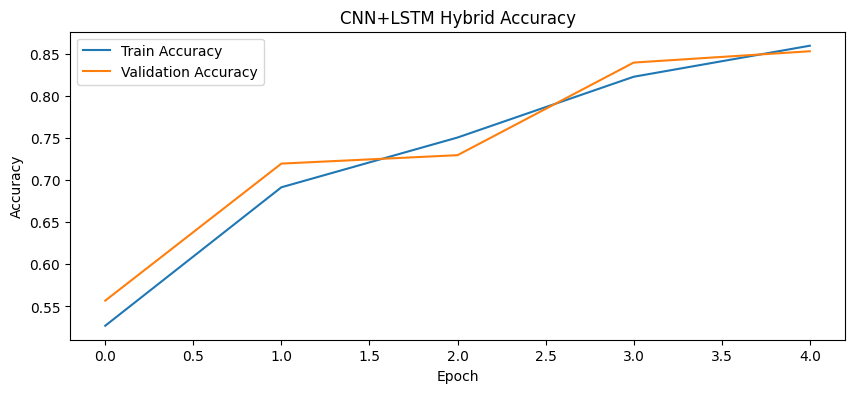

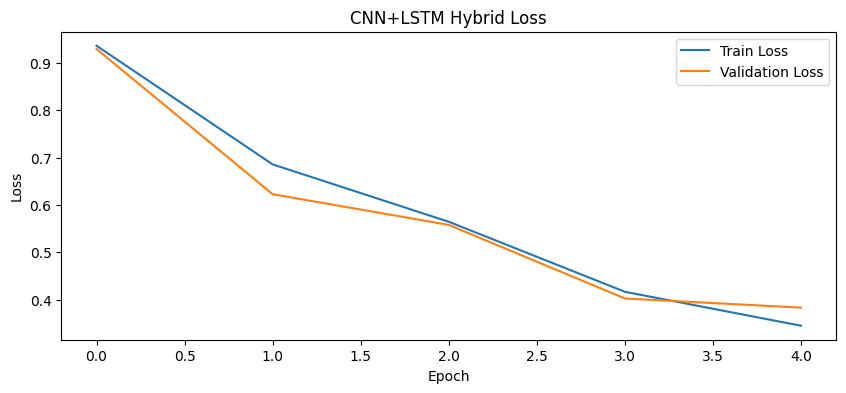

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5525 - loss: 0.9471
CNN+LSTM Hybrid Accuracy: 0.5525318384170532
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

CNN+LSTM Hybrid Classification Report:
              precision    recall  f1-score   support

         Low       0.48      0.92      0.63       878
     Neutral       0.46      0.33      0.39      1008
        High       0.94      0.46      0.61      1017

    accuracy                           0.55      2903
   macro avg       0.63      0.57      0.54      2903
weighted avg       0.63      0.55      0.54      2903



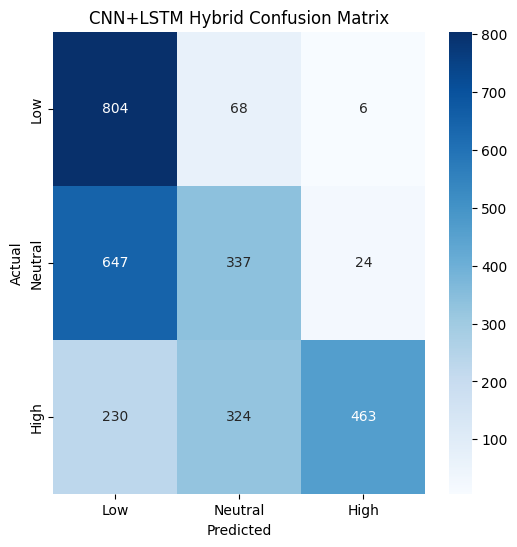

In [26]:
# SECTION 18: CNN+LSTM Evaluation

plot_training_curves(
    history_lstm,
    "CNN+LSTM Hybrid"
)

test_acc_lstm, y_pred_hybrid = evaluate_model(
    model_lstm,
    Xl_test,
    yl_test,
    "CNN+LSTM Hybrid"
)

In [27]:
# SECTION 19: BiLSTM

bi_lstm_model = Sequential()

bi_lstm_model.add(
    Bidirectional(
        LSTM(64),
        input_shape=(94,128)
    )
)

bi_lstm_model.add(
    Dense(
        128,
        activation='relu'
    )
)

bi_lstm_model.add(
    Dropout(0.3)
)

bi_lstm_model.add(
    Dense(
        3,
        activation='softmax'
    )
)

bi_lstm_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

bi_lstm_model.summary()

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,715 (452.01 KB)

 Trainable params: 115,715 (452.01 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# SECTION 20: BiLSTM Training

history_bilstm = bi_lstm_model.fit(
    Xl_train,
    yl_train,
    validation_data=(Xl_val, yl_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.5711 - loss: 0.8707 - val_accuracy: 0.6881 - val_loss: 0.6891 - learning_rate: 5.0000e-04
Epoch 2/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.7094 - loss: 0.6402 - val_accuracy: 0.7305 - val_loss: 0.5938 - learning_rate: 5.0000e-04
Epoch 3/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.7762 - loss: 0.5250 - val_accuracy: 0.8036 - val_loss: 0.4738 - learning_rate: 5.0000e-04
Epoch 4/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.8204 - loss: 0.4270 - val_accuracy: 0.7533 - val_loss: 0.5600 - learning_rate: 2.5000e-04
Epoch 5/50
424/424 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.8428 - loss: 0.3830 - val_accuracy: 0.8377 - val_loss: 0.4131 - learning_rate: 2.5000e-04


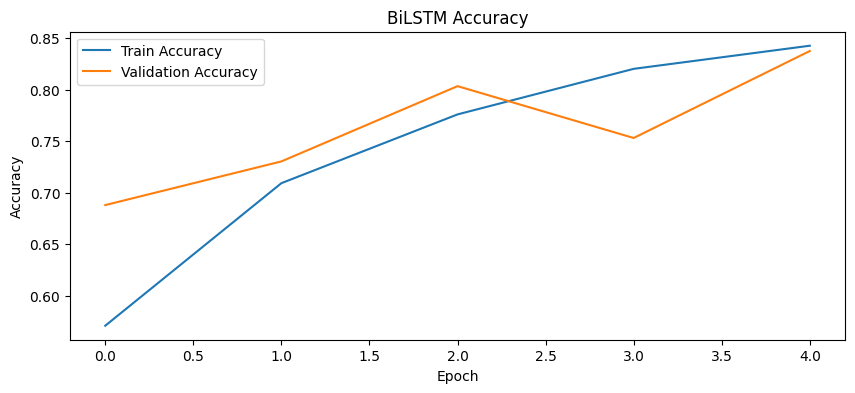

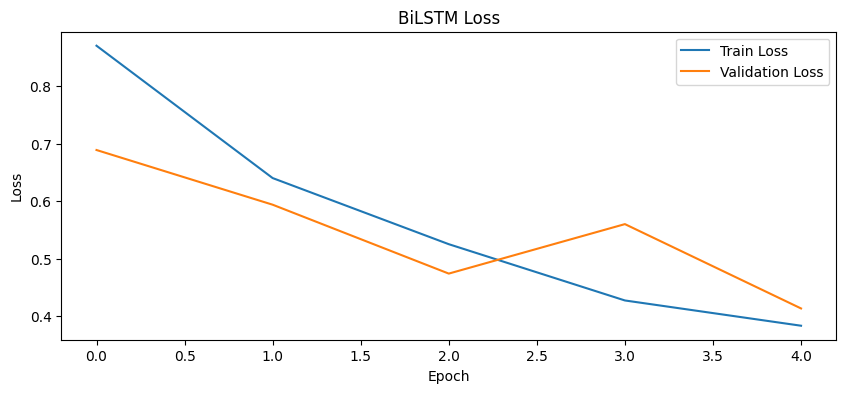

91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6683 - loss: 0.6988
BiLSTM Accuracy: 0.6682742238044739
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

BiLSTM Classification Report:
              precision    recall  f1-score   support

         Low       0.68      0.74      0.71       878
     Neutral       0.61      0.40      0.48      1008
        High       0.69      0.87      0.77      1017

    accuracy                           0.67      2903
   macro avg       0.66      0.67      0.65      2903
weighted avg       0.66      0.67      0.65      2903



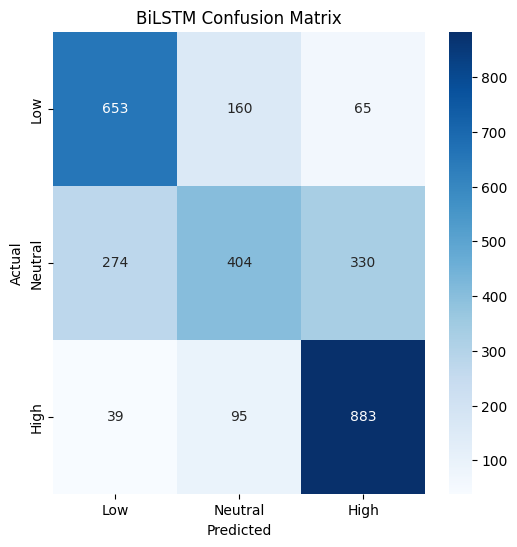

In [29]:
# SECTION 21: BiLSTM Evaluation

plot_training_curves(
    history_bilstm,
    "BiLSTM"
)

test_acc_bi, y_pred_bi = evaluate_model(
    bi_lstm_model,
    Xl_test,
    yl_test,
    "BiLSTM"
)

In [30]:
# SECTION 22: SVM Baseline

X_train_svm = X_train.reshape(
    X_train.shape[0],
    -1
)

X_test_svm = X_test.reshape(
    X_test.shape[0],
    -1
)

svm_model = SVC(
    kernel='rbf'
)

svm_model.fit(
    X_train_svm,
    y_train
)

y_pred_svm = svm_model.predict(
    X_test_svm
)

print(
    "SVM Accuracy:",
    accuracy_score(
        y_test,
        y_pred_svm
    )
)

SVM Accuracy: 0.8298312090940406


SVM Accuracy: 0.8298312090940406

SVM Classification Report:
              precision    recall  f1-score   support

         Low       0.83      0.82      0.83       878
     Neutral       0.77      0.80      0.79      1008
        High       0.89      0.86      0.88      1017

    accuracy                           0.83      2903
   macro avg       0.83      0.83      0.83      2903
weighted avg       0.83      0.83      0.83      2903



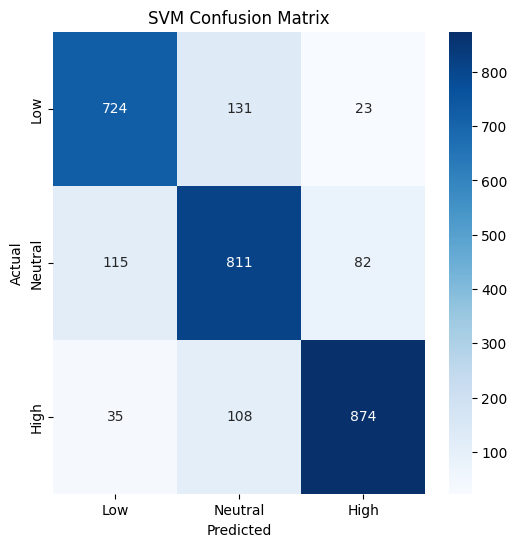

In [31]:
# SECTION 23: SVM Evaluation

svm_acc = accuracy_score(
    y_test,
    y_pred_svm
)

print("SVM Accuracy:", svm_acc)

print("\nSVM Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=target_names
    )
)

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
# SECTION 24: Final Model Comparison

results_df = pd.DataFrame({

    "Model": [
        "SVM Baseline",
        "CNN",
        "LSTM Independent",
        "CNN+LSTM Hybrid",
        "BiLSTM"
    ],

    "Accuracy": [
        svm_acc,
        cnn_test_acc,
        test_acc_lstm_only,
        test_acc_lstm,
        test_acc_bi
    ]
})

print(results_df)

              Model  Accuracy
0      SVM Baseline  0.829831
1               CNN  0.939373
2  LSTM Independent  0.409232
3   CNN+LSTM Hybrid  0.552532
4            BiLSTM  0.668274


In [42]:
cnn_model.save("cnn_baved_model.keras")


In [43]:
import joblib

joblib.dump(
    svm_model,
    "svm_baved.pkl"
)

['svm_baved.pkl']

In [46]:
bi_lstm_model.save(
    "bilstm_baved_model.keras"
)

In [47]:
lstm_model.save(
    "lstm_baved_model.keras"
)

NameError: name 'lstm_model' is not defined